First 5 Rows
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-nul

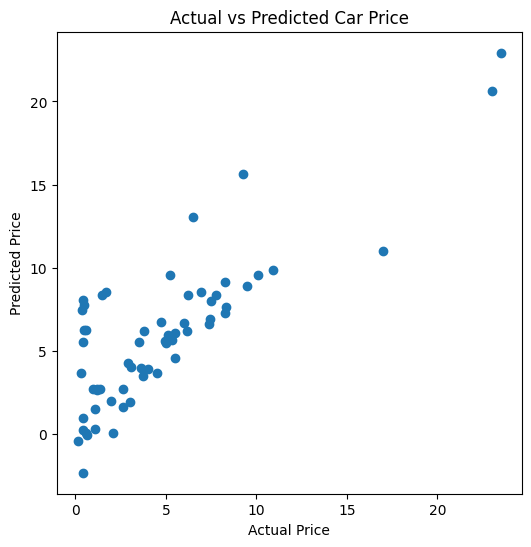


Predicted Price for a Sample Car:
Features (first car in test set):
     Year  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
177  2016           0.57       24000      0               False   

     Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
177               False                   False                       False   

     Car_Name_Bajaj Avenger 150 street  Car_Name_Bajaj Avenger 220  ...  \
177                              False                       False  ...   

     Car_Name_swift  Car_Name_sx4  Car_Name_verna  Car_Name_vitara brezza  \
177           False         False           False                   False   

     Car_Name_wagon r  Car_Name_xcent  Fuel_Type_Diesel  Fuel_Type_Petrol  \
177             False           False             False              True   

     Selling_type_Individual  Transmission_Manual  
177                     True                False  

[1 rows x 105 columns]
Actual Price (first car in test set): 0.35
Predi

In [6]:


# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
df = pd.read_csv("/content/car data (1).csv")

# Step 3: Display Dataset
print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Step 4: Remove Missing Values
df = df.dropna()

# Step 5: Convert Categorical Columns to Numeric
df = pd.get_dummies(df, drop_first=True)

# Step 6: Select Features and Target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 8: Create Model
model = LinearRegression()

# Step 9: Train Model
model.fit(X_train, y_train)

# Step 10: Predict Prices
predictions = model.predict(X_test)

# Step 11: Model Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Step 12: Compare Actual and Predicted Prices
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

print("\nActual vs Predicted Price")
print(result.head(10))

# Step 13: Plot Graph
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

# Step 14: Predict New Car Price (using a sample from X_test)
# To predict for genuinely new data, you would need to create a DataFrame
# with all the features, including one-hot encoded categorical features,
# matching the columns of the training data (X_train).
# For demonstration, let's predict for the first entry in X_test.
sample_car_features = X_test.iloc[[0]]
predicted_car_price = model.predict(sample_car_features)

print("\nPredicted Price for a Sample Car:")
print(f"Features (first car in test set):\n{sample_car_features}")
print(f"Actual Price (first car in test set): {y_test.iloc[0]:.2f}")
print(f"Predicted Price: {predicted_car_price[0]:.2f}")